Importation des bibliothèques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
from google.colab import files

Chargement des jeux de données

In [ ]:
train = pd.read_csv('/content/donnees_train.csv')
val = pd.read_csv('/content/donnees_val.csv')
test = pd.read_csv('/content/donnees_test.csv')

Définition des colonnes cibles et des features

In [ ]:
target_column = "PuissanceActive (kW)"
feature_columns = [
    'VitesseVent (m/s)', 'DirectionVent (°)', 'Temperature (°C)',
    'Saison', 'Annee', 'Mois', 'Jour', 'Heure','Minute',
    'JourNuit', 'deviation', 'deviation_percentage', 'usability'
]

Préparation des données d'entraînement et de validation

In [ ]:
X_train = train[feature_columns]
y_train = train[target_column]

X_val = val[feature_columns]
y_val = val[target_column]

Filtrage selon la vitesse du vent

In [ ]:
mask_train = (X_train['VitesseVent (m/s)'] > 3) & (X_train['VitesseVent (m/s)'] <= 25)
X_train_filtered = X_train[mask_train]
y_train_filtered = y_train[mask_train]

mask_val = (X_val['VitesseVent (m/s)'] > 3) & (X_val['VitesseVent (m/s)'] <= 25)
X_val_filtered = X_val[mask_val]
y_val_filtered = y_val[mask_val]

Normalisation des données

In [ ]:
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train_filtered)
X_val_scaled = scaler_X.transform(X_val_filtered)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train_filtered.values.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val_filtered.values.reshape(-1, 1)).flatten()

Entraînement du modèle Lasso (coefficients positifs)

In [ ]:
model_lasso = Lasso(alpha=0.001, max_iter=10000, positive=True)
model_lasso.fit(X_train_scaled, y_train_scaled)

Lasso(alpha=0.001, max_iter=10000, positive=True)

Prédiction et évaluation sur les données de validation

In [ ]:
y_val_pred_scaled = model_lasso.predict(X_val_scaled)
y_val_pred_scaled = np.maximum(0, y_val_pred_scaled)
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
y_val_real = y_val_filtered.values

Fusion des données d'entraînement et de validation

In [ ]:
full_train = pd.concat([train, val], ignore_index=True)
X_full = full_train[feature_columns]
y_full = full_train[target_column]

mask_full = (X_full['VitesseVent (m/s)'] > 3) & (X_full['VitesseVent (m/s)'] <= 25)
X_full_filtered = X_full[mask_full]
y_full_filtered = y_full[mask_full]

X_full_scaled = scaler_X.fit_transform(X_full_filtered)
y_full_scaled = scaler_y.fit_transform(y_full_filtered.values.reshape(-1, 1)).flatten()

Ré-entraînement final sur l’ensemble des données

In [ ]:
model_final = Lasso(alpha=0.001, max_iter=10000, positive=True)
model_final.fit(X_full_scaled, y_full_scaled)

Lasso(alpha=0.001, max_iter=10000, positive=True)

Préparation et prédiction

In [ ]:
test.dropna(inplace=True)
test.reset_index(drop=True, inplace=True)

X_test = test[feature_columns]
y_test = test[target_column]

mask_test = (X_test['VitesseVent (m/s)'] > 3) & (X_test['VitesseVent (m/s)'] <= 25)
X_test_masked = X_test[mask_test]
y_test_masked = y_test[mask_test]

X_test_scaled = scaler_X.transform(X_test_masked)
y_pred_scaled = model_final.predict(X_test_scaled)
y_pred_scaled = np.maximum(0, y_pred_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

y_pred_final = np.zeros(len(X_test))
y_pred_final[mask_test] = y_pred
y_pred_final[~mask_test] = 0

Évaluation

Avec mask

In [2]:
y_test_used = y_test[mask_test]/ 1000
y_pred_used = y_pred_final[mask_test]/ 1000

mse = mean_squared_error(y_test_used, y_pred_used)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_used, y_pred_used)
r2 = r2_score(y_test_used, y_pred_used)
mape = np.mean(np.abs((y_test_used - y_pred_used) / y_test_used.clip(lower=1e-8))) * 100
smape = 100 * np.mean(
    2 * np.abs(y_pred_used - y_test_used) / (np.abs(y_test_used) + np.abs(y_pred_used) + 1e-8)
)
range_y = np.max(y_test_used) - np.min(y_test_used)
nrmse_range = (rmse / range_y) * 100
nmse_range = (mse / (range_y ** 2)) * 100
nmae = (mae / range_y) * 100 if range_y > 0 else float("inf")

print("Évaluation sur test filtré uniquement (VitesseVent > 3 et <= 25 m/s) :")
print(f" - MSE   : {mse:.4f}MW²")
print(f" - RMSE  : {rmse:.4f}MW")
print(f" - MAE   : {mae:.4f}MW")
print(f" - R2    : {r2:.4f}")
print(f" - MAPE  : {mape:.4f}%")
print(f" - SMAPE  : {smape:.4f}%")
print(f" - NRMSE : {nrmse_range:.4f}%")
print(f" - NMSE  : {nmse_range:.4f}%")
print(f" - NMAE   : {nmae:.4f}%")

Évaluation sur test filtré uniquement (VitesseVent > 3 et <= 25 m/s) :
 - MSE   : 0.2614MW²
 - RMSE  : 0.5113MW
 - MAE   : 0.4033MW
 - R2    : 0.9289
 - MAPE  : 41.2379%
 - SMAPE  : 52.2961%
 - NRMSE : 5.0400%
 - NMSE  : 0.2540%
 - NMAE   : 3.9760%


sur lenssemble des données

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Conversion en mégawatts (MW)
y_test_mw = y_test / 1000
y_pred_mw = y_pred_final / 1000

# Calcul des métriques
mse = mean_squared_error(y_test_mw, y_pred_mw)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_mw, y_pred_mw)
r2 = r2_score(y_test_mw, y_pred_mw)
mape = np.mean(np.abs((y_test_mw - y_pred_mw) / y_test_mw.clip(lower=1e-8))) * 100
smape = 100 * np.mean(
    2 * np.abs(y_pred_mw - y_test_mw) / (np.abs(y_test_mw) + np.abs(y_pred_mw) + 1e-8)
)
range_y = np.max(y_test_mw) - np.min(y_test_mw)
nrmse_range = (rmse / range_y) * 100 if range_y > 0 else float("inf")
nmse_range = (mse / (range_y ** 2)) * 100 if range_y > 0 else float("inf")
nmae = (mae / range_y) * 100 if range_y > 0 else float("inf")

print("Évaluation sur le jeu de test (en MW) :")
print(f" - MSE    : {mse:.4f} MW²")
print(f" - RMSE   : {rmse:.4f} MW")
print(f" - MAE    : {mae:.4f} MW")
print(f" - R2     : {r2:.4f}")
print(f" - MAPE   : {mape:.4f}%")
print(f" - SMAPE  : {smape:.4f}%")
print(f" - NMSE   : {nmse_range:.4f}%")
print(f" - NRMSE  : {nrmse_range:.4f}%")
print(f" - NMAE   : {nmae:.4f}%")

Évaluation sur le jeu de test (en MW) :
 - MSE    : 0.2176 MW²
 - RMSE   : 0.4665 MW
 - MAE    : 0.3358 MW
 - R2     : 0.9375
 - MAPE   : 34.3474%
 - SMAPE  : 43.5685%
 - NMSE   : 0.2092%
 - NRMSE  : 4.5736%
 - NMAE   : 3.2922%


Visualisation des prédictions

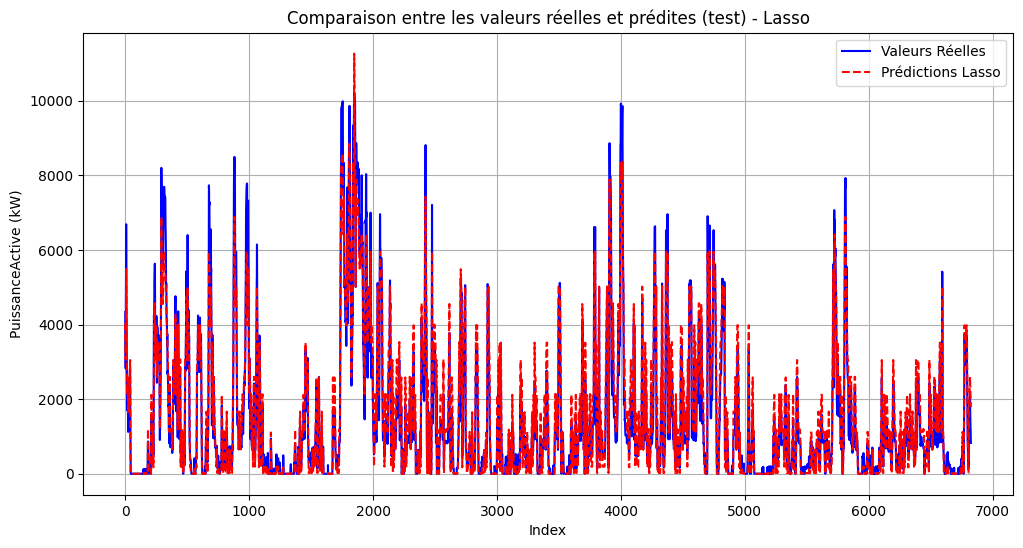

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Valeurs Réelles', color='blue')
plt.plot(y_pred_final, label='Prédictions Lasso', color='red', linestyle='--')
plt.title("Comparaison entre les valeurs réelles et prédites (test) - Lasso")
plt.xlabel("Index")
plt.ylabel("PuissanceActive (kW)")
plt.legend()
plt.grid(True)
plt.show()

Évaluation par plage de production

Avec mask

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Fonction SMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

# Fonction d'évaluation par plage
def eval_par_plage(y_true, y_pred, plage_name, mask):
    # Conversion en MW
    y_true_plage = y_true[mask] / 1000
    y_pred_plage = y_pred[mask] / 1000

    if len(y_true_plage) == 0:
        print(f"\nAucune donnée dans la plage '{plage_name}'.")
        return

    mse_p = mean_squared_error(y_true_plage, y_pred_plage)
    rmse_p = np.sqrt(mse_p)
    mae_p = mean_absolute_error(y_true_plage, y_pred_plage)
    r2_p = r2_score(y_true_plage, y_pred_plage)
    mape_p = np.mean(np.abs((y_true_plage - y_pred_plage) / y_true_plage.clip(lower=1e-8))) * 100
    nmae_p = mae_p / (np.max(y_true_plage) - np.min(y_true_plage) + 1e-8) * 100
    smape_p = smape(y_true_plage, y_pred_plage)

    range_y = np.max(y_true_plage) - np.min(y_true_plage)
    nrmse_range = (rmse_p / range_y) * 100 if range_y > 0 else float('inf')
    nmse_range = (mse_p / (range_y ** 2)) * 100 if range_y > 0 else float('inf')

    print(f"\n Évaluation pour la plage '{plage_name}' (en MW) :")
    print(f" - MSE     : {mse_p:.4f} MW²")
    print(f" - RMSE    : {rmse_p:.4f} MW")
    print(f" - MAE     : {mae_p:.4f} MW")
    print(f" - R2      : {r2_p:.4f}")
    print(f" - MAPE    : {mape_p:.4f}%")
    print(f" - SMAPE   : {smape_p:.4f}%")
    print(f" - NMSE    : {nmse_range:.4f}%")
    print(f" - NRMSE   : {nrmse_range:.4f}%")
    print(f" - NMAE    : {nmae_p:.4f}%")


mask_test = (X_test['VitesseVent (m/s)'] > 3) & (X_test['VitesseVent (m/s)'] <= 25)

# Filtrer les vraies valeurs et les prédictions
y_test_masked = y_test[mask_test]
y_pred_masked = y_pred_final[mask_test]

# Définir les masques de plage de production (sur les données filtrées)
mask_basse = y_test_masked < 1000
mask_moyenne = (y_test_masked >= 1000) & (y_test_masked < 8000)
mask_haute = y_test_masked >= 8000

# Évaluer par plage
eval_par_plage(y_test_masked, y_pred_masked, 'Basse production (<1000)', mask_basse)
eval_par_plage(y_test_masked, y_pred_masked, 'Moyenne production (1000-8000)', mask_moyenne)
eval_par_plage(y_test_masked, y_pred_masked, 'Haute production (>=8000)', mask_haute)


 Évaluation pour la plage 'Basse production (<1000)' (en MW) :
 - MSE     : 0.0818 MW²
 - RMSE    : 0.2860 MW
 - MAE     : 0.2383 MW
 - R2      : -0.0328
 - MAPE    : 53.1936%
 - SMAPE   : 77.5920%
 - NMSE    : 9.2018%
 - NRMSE   : 30.3344%
 - NMAE    : 25.2750%

 Évaluation pour la plage 'Moyenne production (1000-8000)' (en MW) :
 - MSE     : 0.4292 MW²
 - RMSE    : 0.6552 MW
 - MAE     : 0.5710 MW
 - R2      : 0.8601
 - MAPE    : 28.1215%
 - SMAPE   : 23.6423%
 - NMSE    : 0.8762%
 - NRMSE   : 9.3604%
 - NMAE    : 8.1584%

 Évaluation pour la plage 'Haute production (>=8000)' (en MW) :
 - MSE     : 1.3974 MW²
 - RMSE    : 1.1821 MW
 - MAE     : 1.1208 MW
 - R2      : -1.5638
 - MAPE    : 12.6110%
 - SMAPE   : 13.5512%
 - NMSE    : 29.7134%
 - NRMSE   : 54.5100%
 - NMAE    : 51.6825%


Sur lenssemble de test

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

def eval_par_plage(y_true, y_pred, plage_name, mask):
    # Conversion en MW
    y_true_plage = y_true[mask] / 1000
    y_pred_plage = y_pred[mask] / 1000

    if len(y_true_plage) == 0:
        print(f"\n Aucune donnée dans la plage '{plage_name}'.")
        return

    mse_p = mean_squared_error(y_true_plage, y_pred_plage)
    rmse_p = np.sqrt(mse_p)
    mae_p = mean_absolute_error(y_true_plage, y_pred_plage)
    r2_p = r2_score(y_true_plage, y_pred_plage)
    mape_p = np.mean(np.abs((y_true_plage - y_pred_plage) / y_true_plage.clip(lower=1e-8))) * 100
    nmae_p = mae_p / (np.max(y_true_plage) - np.min(y_true_plage) + 1e-8) * 100
    smape_p = smape(y_true_plage, y_pred_plage)

    range_y = np.max(y_true_plage) - np.min(y_true_plage)
    nrmse_range = (rmse_p / range_y) * 100 if range_y > 0 else float('inf')
    nmse_range = (mse_p / (range_y ** 2)) * 100 if range_y > 0 else float('inf')

    print(f"\n Évaluation pour la plage '{plage_name}' (en MW) :")
    print(f" - MSE                : {mse_p:.4f} MW²")
    print(f" - RMSE               : {rmse_p:.4f} MW")
    print(f" - MAE                : {mae_p:.4f} MW")
    print(f" - R2                 : {r2_p:.4f}")
    print(f" - MAPE               : {mape_p:.4f}%")
    print(f" - SMAPE              : {smape_p:.4f}%")
    print(f" - NMSE               : {nmse_range:.4f}%")
    print(f" - NRMSE              : {nrmse_range:.4f}%")
    print(f" - NMAE               : {nmae_p:.4f}%")

# Définir les masques pour les plages
mask_basse = y_test < 1000
mask_moyenne = (y_test >= 1000) & (y_test < 8000)
mask_haute = y_test >= 8000

eval_par_plage(y_test, y_pred_final, 'Basse production (<1000)', mask_basse)
eval_par_plage(y_test, y_pred_final, 'Moyenne production (1000-8000)', mask_moyenne)
eval_par_plage(y_test, y_pred_final, 'Haute production (>=8000)', mask_haute)


 Évaluation pour la plage 'Basse production (<1000)' (en MW) :
 - MSE                : 0.0594 MW²
 - RMSE               : 0.2438 MW
 - MAE                : 0.1732 MW
 - R2                 : 0.5083
 - MAPE               : 38.6755%
 - SMAPE              : 56.4277%
 - NMSE               : 5.9603%
 - NRMSE              : 24.4138%
 - NMAE               : 17.3419%

 Évaluation pour la plage 'Moyenne production (1000-8000)' (en MW) :
 - MSE                : 0.4292 MW²
 - RMSE               : 0.6552 MW
 - MAE                : 0.5710 MW
 - R2                 : 0.8601
 - MAPE               : 28.1215%
 - SMAPE              : 23.6423%
 - NMSE               : 0.8762%
 - NRMSE              : 9.3604%
 - NMAE               : 8.1584%

 Évaluation pour la plage 'Haute production (>=8000)' (en MW) :
 - MSE                : 1.3974 MW²
 - RMSE               : 1.1821 MW
 - MAE                : 1.1208 MW
 - R2                 : -1.5638
 - MAPE               : 12.6110%
 - SMAPE              : 13.5512%
 - NMS

Prédiction des 24 dernières heures

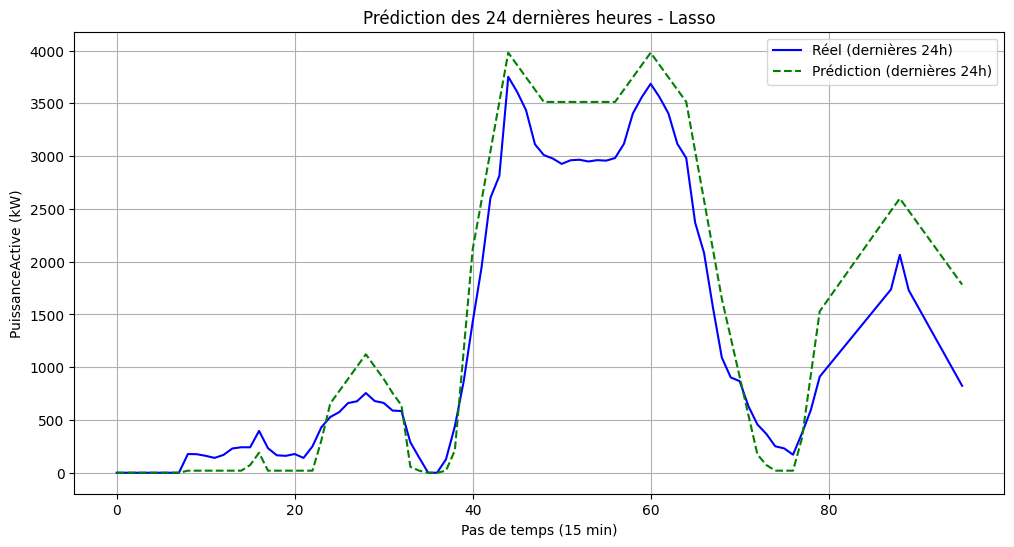

In [ ]:
X_last_24h = test[feature_columns].tail(96).copy()
y_last_24h = test[target_column].tail(96).copy().reset_index(drop=True)

mask_24h = (X_last_24h['VitesseVent (m/s)'] > 3) & (X_last_24h['VitesseVent (m/s)'] <= 25)
X_last_24h_masked = X_last_24h[mask_24h]
X_last_24h_scaled = scaler_X.transform(X_last_24h_masked)

y_pred_24h_scaled = model_final.predict(X_last_24h_scaled)
y_pred_24h_scaled = np.maximum(0, y_pred_24h_scaled)
y_pred_24h = scaler_y.inverse_transform(y_pred_24h_scaled.reshape(-1, 1)).flatten()
y_pred_24h = np.maximum(0, y_pred_24h)

y_pred_24h_final = np.zeros(len(X_last_24h))
y_pred_24h_final[mask_24h.values] = y_pred_24h
y_pred_24h_final[~mask_24h.values] = 0

plt.figure(figsize=(12, 6))
plt.plot(y_last_24h.values, label='Réel (dernières 24h)', color='blue')
plt.plot(y_pred_24h_final, label='Prédiction (dernières 24h)', color='green', linestyle='--')
plt.title("Prédiction des 24 dernières heures - Lasso")
plt.xlabel("Pas de temps (15 min)")
plt.ylabel("PuissanceActive (kW)")
plt.legend()
plt.grid(True)
plt.show()

Sauvegarde et téléchargement du modèle et des prédictions

In [ ]:
joblib.dump(model_final, "/content/lasso_model.pkl")
np.save("/content/predictions_lasso.npy", y_pred_final)

files.download("/content/lasso_model.pkl")
files.download("/content/predictions_lasso.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>